# Results — contagion experiments (H1, H2, E6, open-disorder)

40-seed ensembles from `output/experiments/` (driver `run_experiments.py`). Full numbers and
interpretation are in **`model.md`** section 6. Run from the repo root.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (11, 3.6), 'axes.grid': True, 'grid.alpha': 0.3})

rows = pd.read_csv('output/experiments/rows.csv')
rows = rows[(rows.error.isna()) | (rows.error.astype(str) == '')]
st = rows[rows.regime == 'stressed']
print(f'{len(rows):,} runs, {rows.seed.nunique()} seeds, fundamentals {sorted(rows.fund.unique())}')

def band(g, y):
    a = g.groupby('c')[y].agg(['mean', lambda s: s.quantile(.1), lambda s: s.quantile(.9)])
    a.columns = ['m', 'lo', 'hi']; return a.sort_index()

def line(ax, g, y, label, color=None):
    a = band(g, y); ln, = ax.plot(a.index, a.m, 'o-', ms=4, label=label, color=color)
    ax.fill_between(a.index, a.lo, a.hi, alpha=0.15, color=ln.get_color())

5,520 runs, 40 seeds, fundamentals ['gbm', 'kalman']


## H1 — tiered vs direct clearing

Does the client tier absorb or amplify stress? The breach multiplier is the smallest
amplifier `c` reaching a waterfall level, over seeds.

  fund   mode  level  frac_seeds_breached  breach_c_median  breach_c_p10  breach_c_p90
   gbm direct      3                 1.00             1.75          1.50          2.00
   gbm direct      4                 1.00             2.00          1.75          2.25
   gbm tiered      3                 0.95             2.75          2.17          3.50
   gbm tiered      4                 0.25             3.50          2.98          4.00
kalman direct      3                 1.00             2.25          1.98          2.50
kalman direct      4                 0.95             3.00          2.75          3.65
kalman tiered      3                 0.38             3.50          3.00          4.00
kalman tiered      4                 0.02             4.00          4.00          4.00


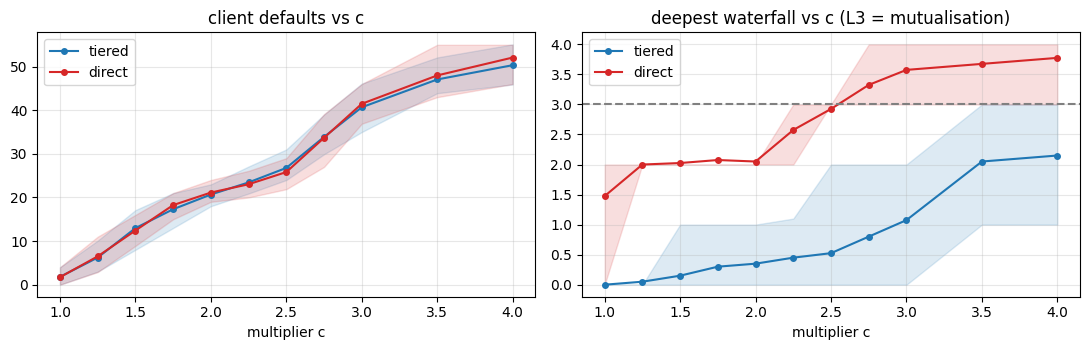

In [2]:
print(pd.read_csv('output/experiments/summary_h1_breach.csv').round(2).to_string(index=False))
h1 = st[(st.im_regime == 'reactive') & (st.reanchor == 1) & (st.scenario == 'gapped') & (st.fund == 'kalman')]
fig, ax = plt.subplots(1, 2)
for mode, col in [('tiered', 'tab:blue'), ('direct', 'tab:red')]:
    line(ax[0], h1[h1['mode'] == mode], 'client_defaults', mode, col)
    line(ax[1], h1[h1['mode'] == mode], 'deepest_waterfall', mode, col)
ax[0].set_title('client defaults vs c'); ax[0].set_xlabel('multiplier c'); ax[0].legend()
ax[1].axhline(3, ls='--', c='grey'); ax[1].set_title('deepest waterfall vs c (L3 = mutualisation)')
ax[1].set_xlabel('multiplier c'); ax[1].legend()
plt.tight_layout(); plt.show()

## H2 — margin regimes

Procyclical (reactive) vs through-the-cycle (flat-12): contagion depth, and the
calm-period collateral cost. The depth ordering is coupled to the cover-2 fund sizing —
see `model.md` section 6.2.

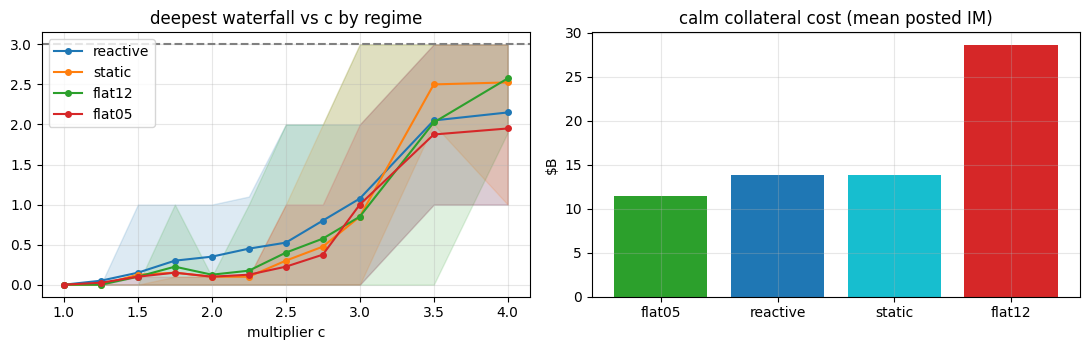

In [3]:
h2 = st[(st['mode'] == 'tiered') & (st.reanchor == 1) & (st.scenario == 'gapped') & (st.fund == 'kalman')]
fig, ax = plt.subplots(1, 2)
for reg in ['reactive', 'static', 'flat12', 'flat05']:
    line(ax[0], h2[h2.im_regime == reg], 'deepest_waterfall', reg)
ax[0].axhline(3, ls='--', c='grey'); ax[0].set_title('deepest waterfall vs c by regime')
ax[0].set_xlabel('multiplier c'); ax[0].legend()
cc = pd.read_csv('output/experiments/summary_h2_calmcost.csv').set_index('im_regime')['im_mean'] / 1e9
cc = cc.reindex(['flat05', 'reactive', 'static', 'flat12'])
ax[1].bar(cc.index, cc.values, color=['tab:green', 'tab:blue', 'tab:cyan', 'tab:red'])
ax[1].set_title('calm collateral cost (mean posted IM)'); ax[1].set_ylabel('$B')
plt.tight_layout(); plt.show()

## E6 — overnight gaps vs a single shock (matched drawdown)

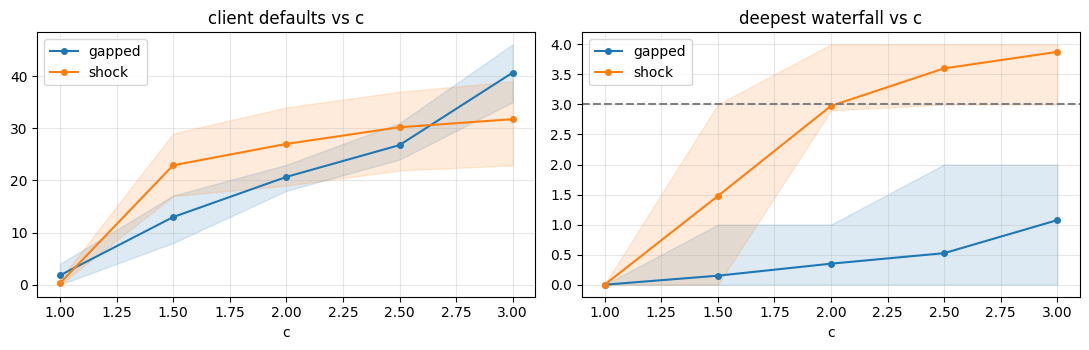

In [4]:
e6 = st[(st.fund == 'kalman') & (st['mode'] == 'tiered') & (st.im_regime == 'reactive')
        & (st.reanchor == 1) & (st.c.isin([1.0, 1.5, 2.0, 2.5, 3.0]))]
fig, ax = plt.subplots(1, 2)
for k, col in [('gapped', 'tab:blue'), ('shock', 'tab:orange')]:
    line(ax[0], e6[e6.scenario == k], 'client_defaults', k, col)
    line(ax[1], e6[e6.scenario == k], 'deepest_waterfall', k, col)
ax[0].set_title('client defaults vs c'); ax[0].set_xlabel('c'); ax[0].legend()
ax[1].axhline(3, ls='--', c='grey'); ax[1].set_title('deepest waterfall vs c'); ax[1].set_xlabel('c'); ax[1].legend()
plt.tight_layout(); plt.show()

## Open-disorder sensitivity

Clean reprice (default) vs a disorderly open (no re-anchor at the gap).

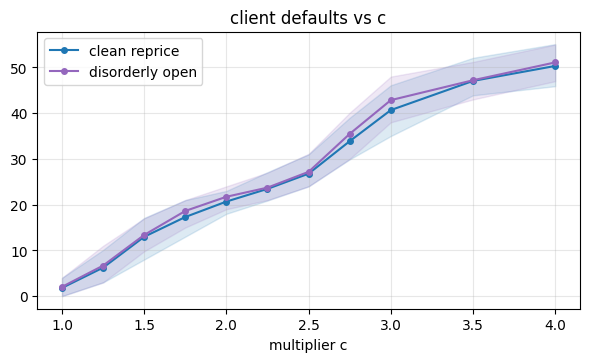

In [5]:
od = st[(st.fund == 'kalman') & (st['mode'] == 'tiered') & (st.im_regime == 'reactive') & (st.scenario == 'gapped')]
fig, ax = plt.subplots(figsize=(7, 3.6))
for ra, lab, col in [(1, 'clean reprice', 'tab:blue'), (0, 'disorderly open', 'tab:purple')]:
    line(ax, od[od.reanchor == ra], 'client_defaults', lab, col)
ax.set_title('client defaults vs c'); ax.set_xlabel('multiplier c'); ax.legend(); plt.show()

## Takeaways

- **H1:** the client tier buys ~1.25x COVID of mutualisation headroom; direct clearing
  mutualises in every seed by ~2.25x, the tiered structure rarely through 4x (relocating
  loss onto member balance sheets). Robust on the SV-MJD path.
- **H2:** reactive margin is cheap in calm but spikes ~6x in stress; through-the-cycle is
  stable but costs ~2x the calm collateral. The waterfall-depth ordering is coupled to the
  cover-2 fund sizing (`model.md` section 6.2).
- **E6:** a single concentrated shock is far worse than the overnight-gapped path at matched
  drawdown — the gap structure is a mitigant.
- **Open-disorder:** a disorderly open worsens contagion only modestly (second-order).